## Verification, Deriving Radar Features

This notebook focuses first on downloading the radar data at each report and allowing the user to manual verify its validity, then on calculating features from said radar data. These features will later be used to train the ML model.

In [ ]:
# Necessary imports below. The pip install necessary in the default Google Colab workspace is also included.
!pip install arm_pyart cartopy

import fsspec
import os
from datetime import datetime, timedelta, timezone
import pyart
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import pandas as pd
import numpy as np
import random
import time

In [3]:
# Script for downloading NEXRAD radar files through the AWS Database with fsspec and S3
# Original author: Brandon Weart, Northern Illinois University
# Edits made by June Graff

"""
This script allows users to download NEXRAD radar files from the AWS Database using the fsspec library.
The user is prompted to enter the start date and time (yyyy-mm-dd HH:MM in UTC), end date and time, radar station code (E.G. KLOT), and the directory to save the radar files.
To run the script, you can either download this and change it to an .ipynb file by changing the extension...
Or you could run it in a terminal as a .py file by doing python /your/path/here/nexrad_download.py

"""

# Set up the S3 filesystem
fs = fsspec.filesystem("s3", anon=True)

# Download the earliest radar file <10 mins after report time
def download_radar(cutoff_dt, station, download_dir):
    fn = ''
    # Ensure the download directory exists
    os.makedirs(download_dir, exist_ok=True)

    # Generate the list of files for the specified date and hour range:
    date_str = cutoff_dt.strftime("%Y/%m/%d")
    date_str_compact = cutoff_dt.strftime("%Y%m%d")
    cutoff_hour = cutoff_dt.hour

    found = False
    for hour in range(cutoff_hour, cutoff_hour + 1):
        hour_str = f"{hour:02d}"
        all_files = fs.glob(
            f"s3://unidata-nexrad-level2/{date_str}/{station}/{station}{date_str_compact}_{hour_str}*"
        )

        filtered_files = sorted([f for f in all_files if not f.endswith("_MDM")])

        for file in filtered_files:
            basename = os.path.basename(file)
            time_part = basename.split("_")[1]
            file_dt = datetime.strptime(f"{date_str} {time_part}", "%Y/%m/%d %H%M%S").replace(tzinfo=timezone.utc)

            if file_dt >= cutoff_dt:
                local_filename = os.path.join(download_dir, 'data')
                try:
                    fn = basename
                    with fs.open(file, "rb") as f_in, open(local_filename, "wb") as f_out:
                        f_out.write(f_in.read())
                    # print(f"Downloaded {local_filename}")
                except Exception as e:
                    print(f"Failed to download {file}: {e}")
                found = True
                break
        if found:
          break
    # print(f"Download completed.")
    fn = 'data'
    return fn

# Returns a single radar image corresponding to the given hail report
# rpt should be a pandas Series; a row of the hail v2 dataframe
def get_radar(rpt):
  # Try to account for timezone issues
  ts1 = (pd.to_datetime(rpt['datetime']) + pd.Timedelta(minutes=60))
  ts1 = ts1.tz_localize('America/Chicago').tz_convert('UTC').to_pydatetime()
  # print(ts1)
  fn = download_radar(ts1, rpt['radar'], 'radar')
  return ts1, fn

# Plots reflectivity imagery associated with a hail report along with the location of the report itself
def plot_radar(rpt, filename, ts1):
  # Handle errors
  try:
    radar = pyart.io.read_nexrad_archive(f'radar/{filename}')
  except OSError as e:
        print(f"[Warning] Skipping file {filename}: {e}")
        return

  display = pyart.graph.RadarMapDisplay(radar)
  fig = plt.figure(figsize=(8, 8))
  ax = plt.axes(projection=ccrs.PlateCarree())

  rptlon = rpt['slon']
  rptlat = rpt['slat']
  ax.set_extent([rptlon-0.3, rptlon+0.3, rptlat-0.3, rptlat+0.3])

  # Plot reflectivity on map
  display.plot_ppi_map('reflectivity', sweep=0, ax=ax, projection=ccrs.PlateCarree(), lat_0=radar.latitude['data'][0], lon_0=radar.longitude['data'][0], cmap="ChaseSpectral")

  # Plot the location of the associated hail report
  ax.plot(rptlon, rptlat, marker='^', color='white', markersize=12, transform=ccrs.PlateCarree())
  ax.plot(rptlon, rptlat, marker='^', color='green', markersize=8, transform=ccrs.PlateCarree())
  ax.text(rptlon, rptlat, f'{rpt['mag']} in.', transform=ccrs.PlateCarree())

  # Plot the radar location (if desired, it's usually apparent anyway)
  # radar = rpt['radar']
  # r = radar_sites[radar_sites['id']==radar]
  # ax.plot(r['lon'], r['lat'], marker='o', color='white', markersize=6, transform=ccrs.PlateCarree())
  # ax.plot(r['lon'], r['lat'], marker='o', color='black', markersize=3, transform=ccrs.PlateCarree())
  # ax.text(r['lon'], r['lat'], radar, transform=ccrs.PlateCarree())

  plt.title(f'{ts1} Reflectivity and hail report')
  plt.show()

### Manual Verification

*The hail_v2.csv file obtained from initial pre-processing must be uploaded into the current working directory.*

This was originally written with the intention of grouping hail reports into size bins rather than just sig-severe/non sig-severe, but the verification process is essentially the same.

VERIFICATION PROCESS: The user is presented with a hail report overlaid on its corresponding radar image. The user may type 'y' in the console to save the report in a list of verified ones, or anything else to discard it if the radar image is malformed, mismatched, etc. The verification begins with the largest hail size bin, automatically moving to the next-smallest once that bin has been exhausted. The user may also type 'NEXT' in the console to manually switch to the next bin.

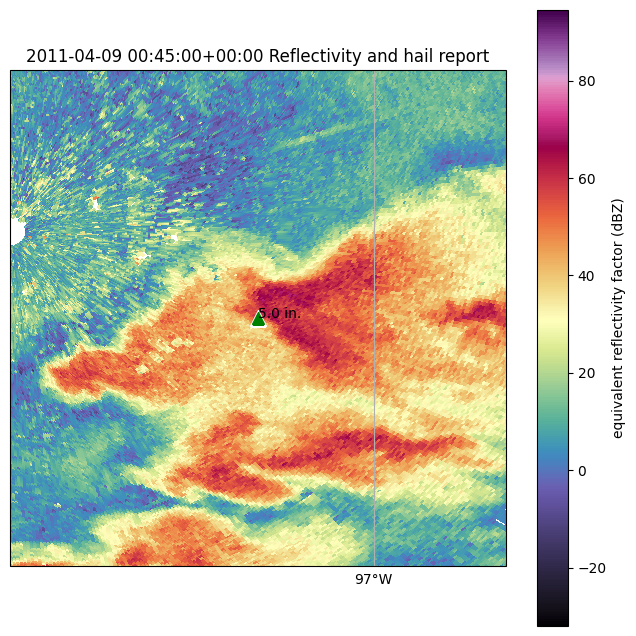

y

#0 EVALUATED:
1/5
INDEX: 2532
INDICES SAVED: 1;0;0;0;0


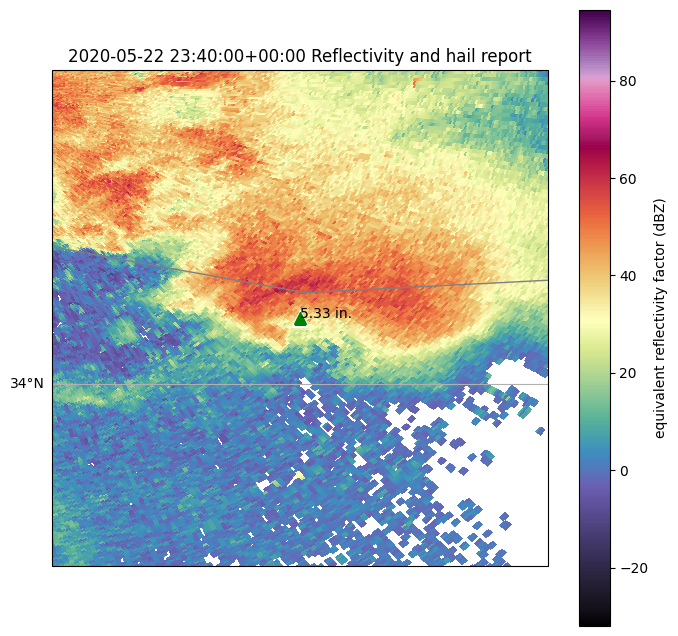

y

#0 EVALUATED:
2/5
INDEX: 19292
INDICES SAVED: 2;0;0;0;0


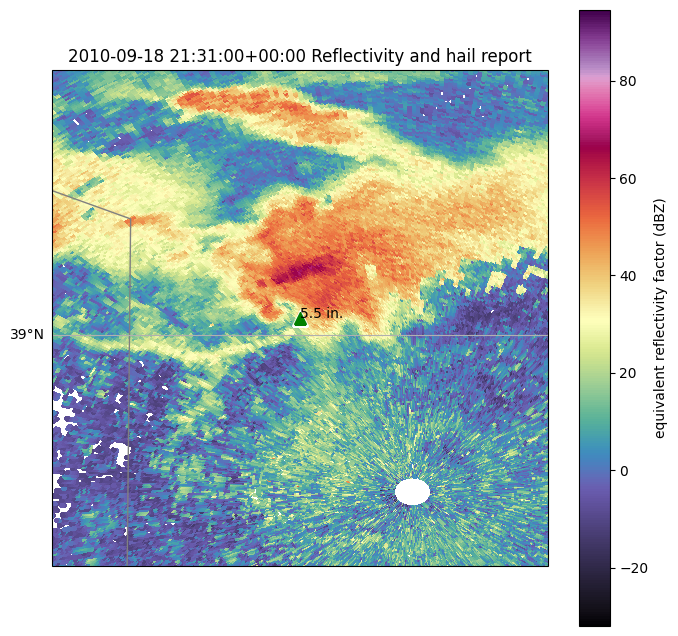

y

#0 EVALUATED:
3/5
INDEX: 1473
INDICES SAVED: 3;0;0;0;0


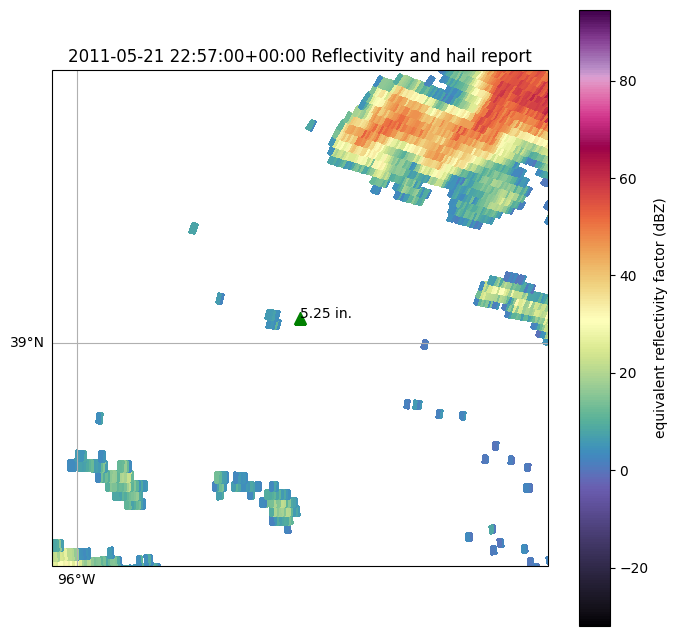

n

#0 EVALUATED:
4/5
INDEX: 2841
INDICES SAVED: 3;0;0;0;0


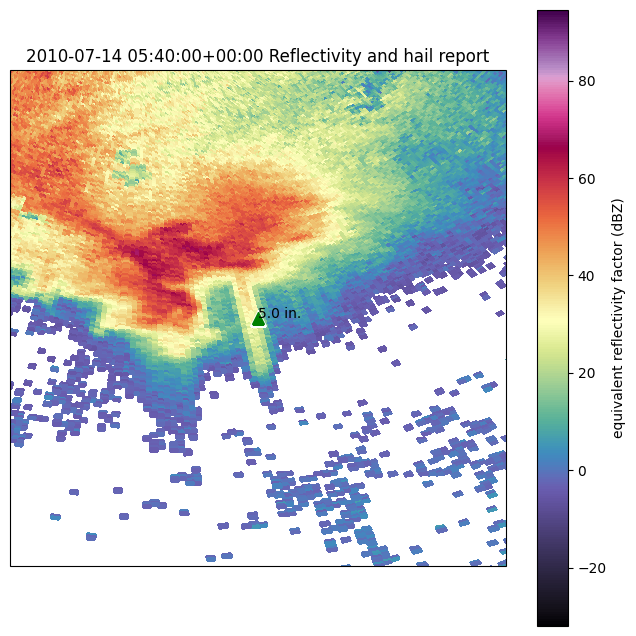

NEXT

#0 EVALUATED:
5/5
INDEX: 1231
INDICES SAVED: 3;0;0;0;0


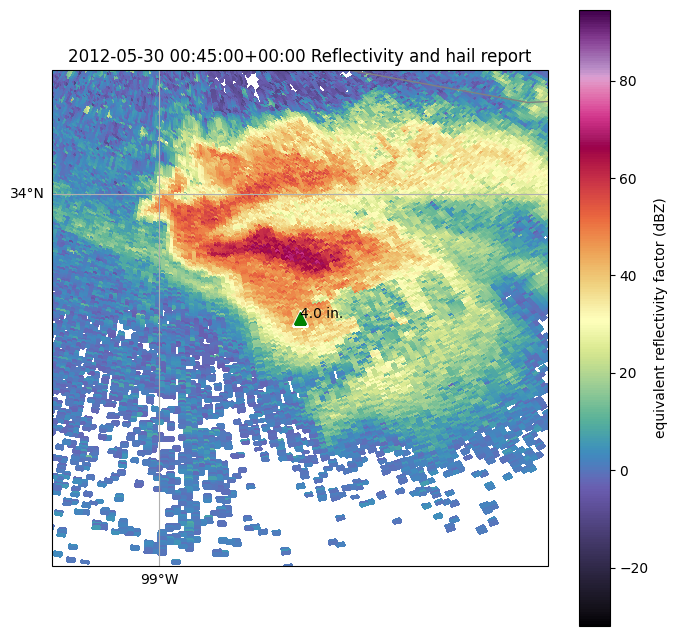

y

#1 EVALUATED:
1/78
INDEX: 5757
INDICES SAVED: 3;1;0;0;0


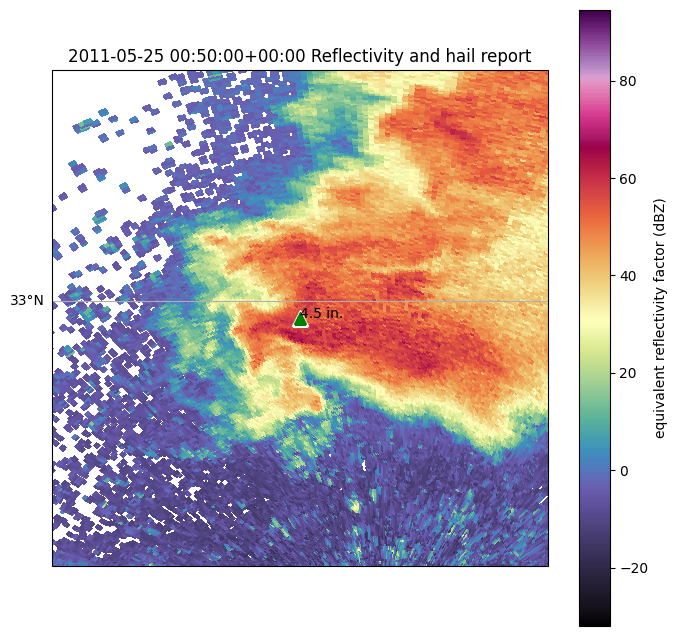

y

#1 EVALUATED:
2/78
INDEX: 3079
INDICES SAVED: 3;2;0;0;0


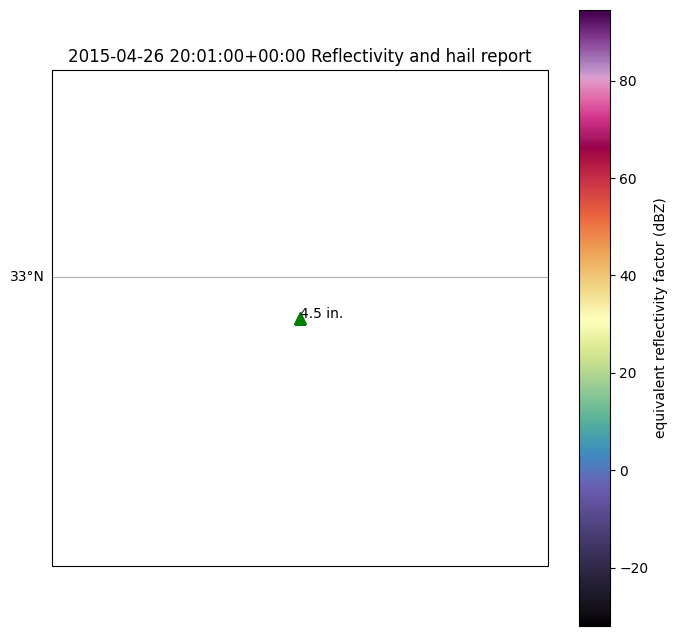

n

#1 EVALUATED:
3/78
INDEX: 10613
INDICES SAVED: 3;2;0;0;0


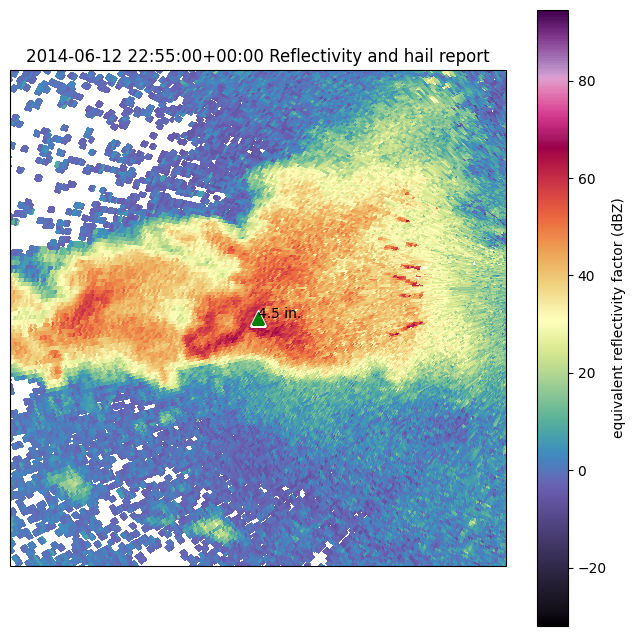

y

#1 EVALUATED:
4/78
INDEX: 9446
INDICES SAVED: 3;3;0;0;0


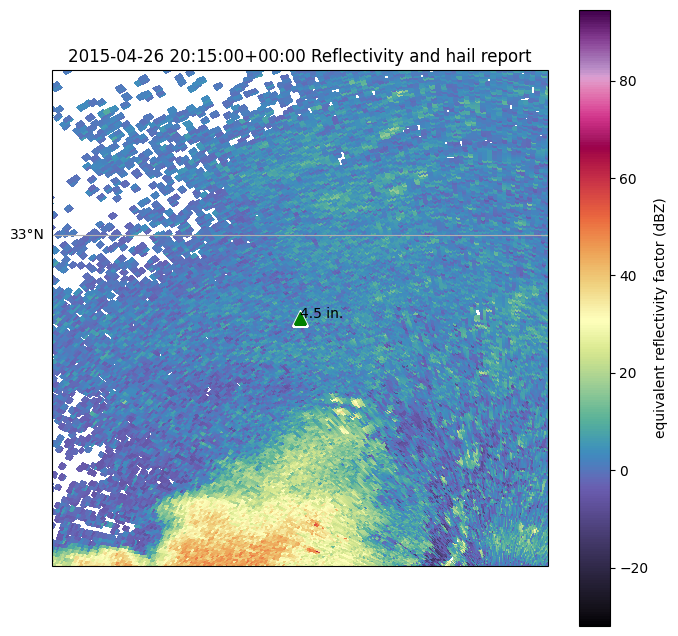

n

#1 EVALUATED:
5/78
INDEX: 10615
INDICES SAVED: 3;3;0;0;0


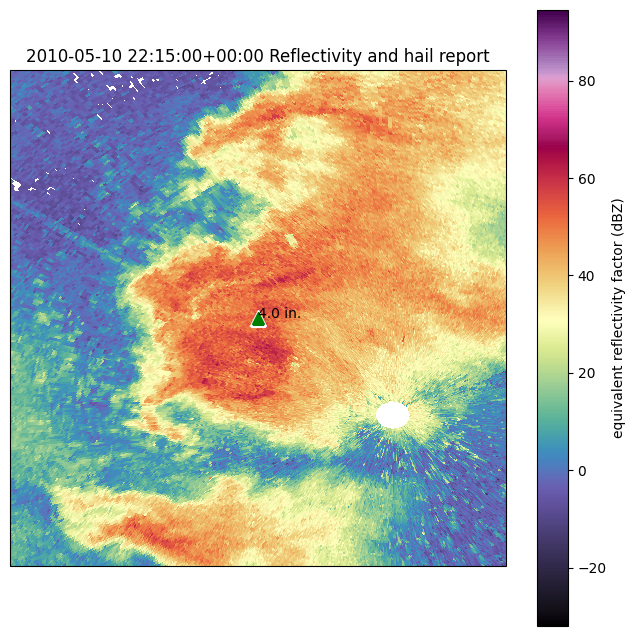

y

#1 EVALUATED:
6/78
INDEX: 418
INDICES SAVED: 3;4;0;0;0


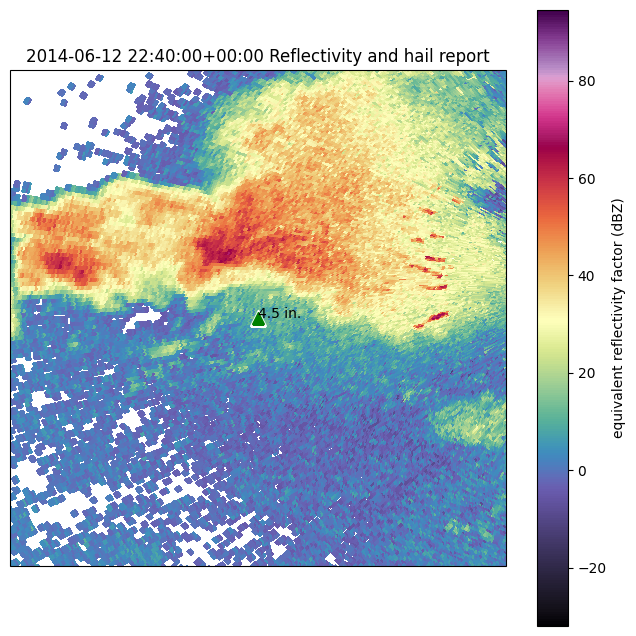

y

#1 EVALUATED:
7/78
INDEX: 9443
INDICES SAVED: 3;5;0;0;0


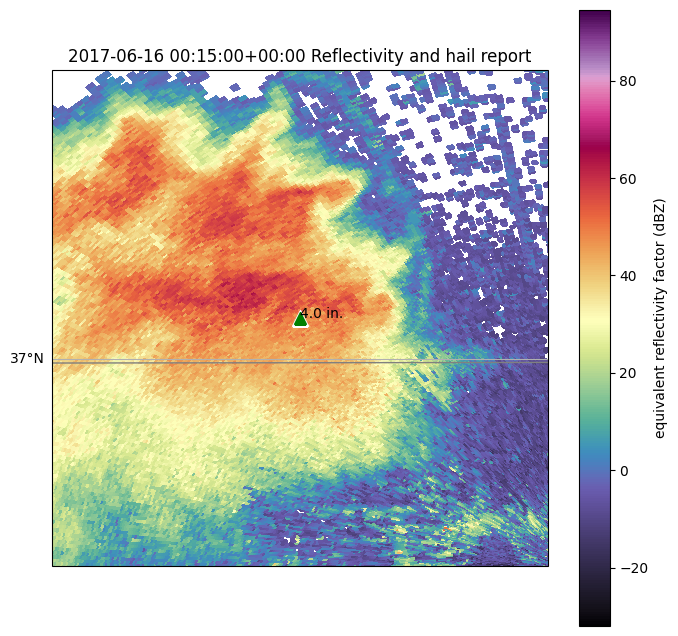

next

#1 EVALUATED:
8/78
INDEX: 15122
INDICES SAVED: 3;5;0;0;0


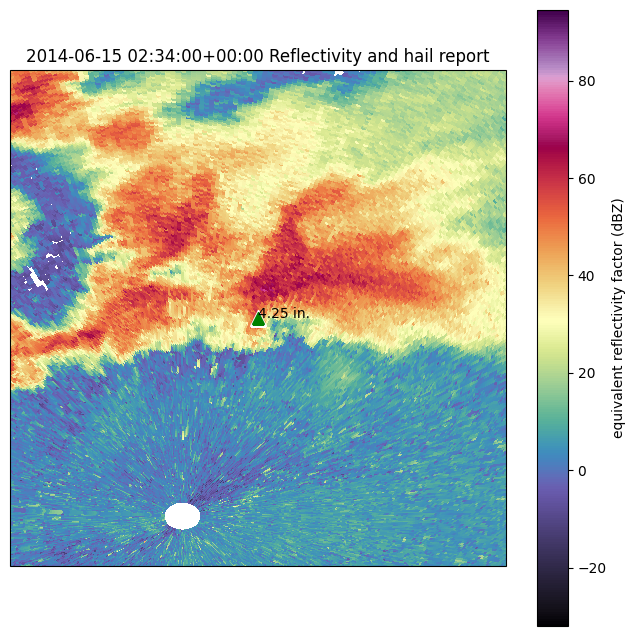

NEXT

#1 EVALUATED:
9/78
INDEX: 9495
INDICES SAVED: 3;5;0;0;0


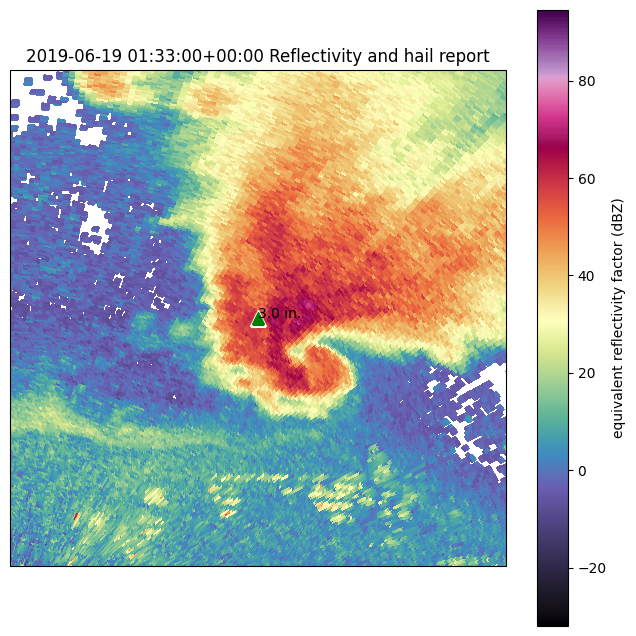

KeyboardInterrupt: Interrupted by user

In [9]:
hail_data = pd.read_csv('hail_v2.csv')

# Saves indices of rpts with GOOD RADAR DATA by size bin
good_indices = [[],[],[],[],[]]

# Conditions for each bin, 1-inch bins then 5+". This returns only the indices of the reports
i1 = np.where(hail_data['mag'] >= 5)[0].tolist()
i2 = np.where((hail_data['mag'] >= 4) & (hail_data['mag'] < 5))[0].tolist()
i3 = np.where((hail_data['mag'] >= 3) & (hail_data['mag'] < 4))[0].tolist()
i4 = np.where((hail_data['mag'] >= 2) & (hail_data['mag'] < 3))[0].tolist()
i5 = np.where(hail_data['mag'] < 2)[0].tolist()
ix = [i1, i2, i3, i4, i5]

# Making sure we get as many of the limited large hail reports as possible: start with 5+, then 4-5, then everything below.
for j in range(len(ix)):
  l = ix[j]
  done = []
  line = ''
  while(line!='NEXT'):
    # if we have looped through everything in a category then go to next one
    unused = list(set(l) - set(done))
    if len(unused) == 0:
      break
    # pick index at random from stuff that hasn't already been done
    idx = unused[random.randint(0, len(unused)-1)]
    rpt = hail_data.iloc[idx]

    # DISPLAY
    ts1, filename = get_radar(rpt)
    plot_radar(rpt, filename, ts1)
    # let colab render first so it doesn't override the input box
    time.sleep(0.1)

    # let June evaluate
    line = input()
    done.append(idx)
    if line == 'y':
      good_indices[j].append(idx)
    # print
    print(f"\n#{j} EVALUATED:\n{len(done)}/{len(l)}\nINDEX: {idx}\nINDICES SAVED: {len(good_indices[0])};{len(good_indices[1])};{len(good_indices[2])};{len(good_indices[3])};{len(good_indices[4])}")
    # if the next input is NEXT, it switches to the next hail size bin.
print(good_indices)

##Developing features for our model

*This needs to be run after the above chunk, as it relies on the `good_indices` list produced by the manual verification process.*

We want to mask our data only to the area where DBZ ≥ 30 because that is a threshold often used to demarcate convection. This should also help to reduce noisy background signals. After that, inside that specific area, we want to calculate:
- Area over which DBZ ≥ 30, ≥ 50, ≥ 60
- Max, mean DBZ
- Mean, mean, min ZDR
- Mean, min CC

We iterate through the hail reports (only the previously-verified indices) and, for each one: download radar -> mask to the area 0.3 degrees lat/lon in any direction from report -> calculate the variables -> add them to the hail csv.

Once this step is done we are free to begin developing our ML model.

In [12]:
# This chunk and the next were used to produce the FINAL dataset (hail_v3.csv), which is included in the GitHub.
# Due to issues with Google Colab, the data had to be processed in several parts and combined later.
import time
import gc

c=0
e=0
# s=4
cr=0
hail_data = pd.read_csv('hail_v2.csv')
hail_data_3 = pd.DataFrame()

# Iterate through bins
for row in good_indices:
  cr = cr+1
  e=0
  c=0
  for i in row:
    # Get fields of radar data
    rpt = hail_data.iloc[i]
    ts1, filename = get_radar(rpt)
    radar = pyart.io.read_nexrad_archive("radar/data")
    sweep = radar.get_slice(0)

    # It's all in a big try/catch because I don't know how else to account for this, some files do not have zdr/cc and cannot be used
    try:
      dbz = radar.fields['reflectivity']['data'][sweep]
      zdr = radar.fields['differential_reflectivity']['data'][sweep]
      cc = radar.fields['cross_correlation_ratio']['data'][sweep]
      # To help with memory usage
      dbz = dbz.astype('float32')
      zdr = zdr.astype('float32')
      cc = cc.astype('float32')

      # Filter by lat and lon and minimum dbz
      gate_lat, gate_lon, gate_alt = radar.get_gate_lat_lon_alt(0)
      rptlon = rpt['slon']
      rptlat = rpt['slat']
      b = [rptlon-0.3, rptlon+0.3, rptlat-0.3, rptlat+0.3]
      dbz_filter = dbz[(gate_lon >= b[0]) & (gate_lon <= b[1]) & (gate_lat >= b[2]) & (gate_lat <= b[3]) & (dbz >= 30)]
      zdr_filter = zdr[(gate_lon >= b[0]) & (gate_lon <= b[1]) & (gate_lat >= b[2]) & (gate_lat <= b[3]) & (dbz >= 30)]
      # Filtering out unrealistic values because ew
      zdr_filter = zdr_filter[(zdr_filter > -2) & (zdr_filter < 5)]
      cc_filter = cc[(gate_lon >= b[0]) & (gate_lon <= b[1]) & (gate_lat >= b[2]) & (gate_lat <= b[3]) & (dbz >= 30)]

      print(f'\n--- Bin {cr}/5: report {c}/{len(row)}')
      # max/mean dbz
      max_dbz = dbz_filter.max()
      mean_dbz = round(dbz_filter.mean(), 1)
      rpt['max_dbz'] = max_dbz
      rpt['mean_dbz'] = mean_dbz

      # max/mean/min zdr
      max_zdr = zdr_filter.max()
      mean_zdr = round(zdr_filter.mean(), 1)
      min_zdr = zdr_filter.min()
      rpt['max_zdr'] = max_zdr
      rpt['mean_zdr'] = mean_zdr
      rpt['min_zdr'] = min_zdr

      # mean/min cc
      mean_cc = round(cc_filter.mean(), 2)
      min_cc = cc_filter.min()
      rpt['mean_cc'] = mean_cc
      rpt['min_cc'] = min_cc

      # number of 30/50dbz+ pixels.
      # not as reliable as actually finding the area but that feels too sophisticated for me right now
      count_30dbz = dbz_filter.size
      count_50dbz = dbz_filter[dbz_filter >= 50].size
      count_60dbz = dbz_filter[dbz_filter >= 60].size
      rpt['count_30dbz'] = count_30dbz
      rpt['count_50dbz'] = count_50dbz
      rpt['count_60dbz'] = count_60dbz

      # Add to the dataframe with new columns included
      print('dbz: ', max_dbz, mean_dbz, '\nzdr: ', max_zdr, mean_zdr, min_zdr, '\ncc: ', mean_cc, min_cc, '\n', count_30dbz, count_50dbz, count_60dbz)
      hail_data_3 = pd.concat([hail_data_3, pd.DataFrame([rpt])], ignore_index = True)

      # Helps with memory usage please stop crashing
      del radar, dbz, zdr, cc, gate_lat, gate_lon
      gc.collect()
    except KeyError:
      e=e+1
      print(f'\n--- Missing ZDR/CC, skipping this file ({e} errors of {c+e} total)')
    c=c+1
hail_data_3.to_csv('hail_v3.csv')
display(hail_data_3)


--- Missing ZDR/CC, skipping this file (1 errors of 1 total)

--- Bin 1/5: report 1/3
dbz:  64.0 41.9 
zdr:  4.9375 2.0 -1.9375 
cc:  0.97 0.20833333 
 17858 2646 40

--- Missing ZDR/CC, skipping this file (2 errors of 4 total)

--- Missing ZDR/CC, skipping this file (1 errors of 1 total)

--- Missing ZDR/CC, skipping this file (2 errors of 3 total)

--- Bin 2/5: report 2/5
dbz:  68.0 41.4 
zdr:  4.9375 1.9 -1.9375 
cc:  0.96 0.20833333 
 11466 1599 167

--- Missing ZDR/CC, skipping this file (3 errors of 6 total)

--- Bin 2/5: report 4/5
dbz:  69.5 39.9 
zdr:  4.9375 1.6 -1.9375 
cc:  0.96 0.20833333 
 10574 1157 137


,yr,mo,dy,date,time,mag,slat,slon,radar,radar_dist,...,max_dbz,mean_dbz,max_zdr,mean_zdr,min_zdr,mean_cc,min_cc,count_30dbz,count_50dbz,count_60dbz
0,2020,5,22,2020-05-22,17:40:00,5.33,34.08,-98.56,KFDR,47.494218,...,64.0,41.9,4.9375,2.0,-1.9375,0.97,0.208333,17858,2646,40
1,2014,6,12,2014-06-12,16:55:00,4.50,32.50,-99.66,KDYX,39.710006,...,68.0,41.4,4.9375,1.9,-1.9375,0.96,0.208333,11466,1599,167
2,2014,6,12,2014-06-12,16:40:00,4.50,32.49,-99.69,KDYX,42.644500,...,69.5,39.9,4.9375,1.6,-1.9375,0.96,0.208333,10574,1157,137


In [16]:
# Coming back to make a few more derived variables to help the model's performance
hail_data = pd.read_csv('hail_v3.csv')

hail_data['ratio_50_30'] = hail_data['count_50dbz'] / (hail_data['count_30dbz'] + 1)
hail_data['ratio_60_50'] = hail_data['count_60dbz'] / (hail_data['count_50dbz'] + 1)
hail_data['zdr_range'] = hail_data['max_zdr'] - hail_data['min_zdr']
hail_data = hail_data.drop(['Unnamed: 0'], axis=1)

# One final bit of processing, create column of sig vs. not sig hail
sig = []
for i, row in hail_data.iterrows():
  sig.append(int(row['mag'] >= 2.0))
hail_data['sig'] = sig

display(hail_data[:5])

# hail_v4 is the final dataset!
hail_data.to_csv('hail_v4.csv')

,yr,mo,dy,date,time,mag,slat,slon,radar,radar_dist,...,min_zdr,mean_cc,min_cc,count_30dbz,count_50dbz,count_60dbz,ratio_50_30,ratio_60_50,zdr_range,sig
0,2020,5,22,2020-05-22,17:40:00,5.33,34.08,-98.56,KFDR,47.494218,...,-1.9375,0.97,0.208333,17858,2646,40,0.148161,0.015111,6.875,1
1,2014,6,12,2014-06-12,16:55:00,4.50,32.50,-99.66,KDYX,39.710006,...,-1.9375,0.96,0.208333,11466,1599,167,0.139444,0.104375,6.875,1
2,2014,6,12,2014-06-12,16:40:00,4.50,32.49,-99.69,KDYX,42.644500,...,-1.9375,0.96,0.208333,10574,1157,137,0.109409,0.118307,6.875,1
